Abstracto (Motivación y Audiencia)

Motivación: En la industria del e-commerce, la logística y la puntualidad en los envíos son factores críticos que determinan la retención de clientes y la reputación de la marca. Los retrasos generan altos costos en atención al cliente y devoluciones. La motivación de este proyecto es analizar los datos históricos de envíos de una empresa de comercio electrónico para encontrar los factores que causan retrasos y, posteriormente, entrenar modelos de Machine Learning capaces de predecir de forma proactiva si un paquete llegará a tiempo o no.

Audiencia: Este proyecto está dirigido a:

Gerentes de Operaciones y Logística: Para identificar cuellos de botella según el peso del paquete, el almacén de origen o el método de envío.

Equipos de Atención al Cliente (Customer Service): Para anticiparse a los reclamos y gestionar la comunicación con clientes que probablemente sufrirán un retraso.

Directores de E-commerce: Para tomar decisiones estratégicas sobre qué métodos de envío priorizar.

Preguntas e Hipótesis que buscamos responder

Problema Principal (Machine Learning): ¿Podemos predecir con precisión si un producto llegará a tiempo (Clasificación) basándonos en sus características como peso, costo, descuento ofrecido y método de envío?

Pregunta EDA 1: ¿Existe una relación directa entre el peso del producto y los retrasos en la entrega?

Pregunta EDA 2: ¿Qué método de envío (Barco, Avión, Camión) presenta la mayor tasa de incumplimiento en los tiempos?

Pregunta EDA 3: ¿Los productos con mayores descuentos son los que más se retrasan?

In [3]:
# Importamos la librería pandas
import pandas as pd

# 1. Definimos la URL pública del dataset de E-commerce (Superstore Sales)
url_dataset = 'https://raw.githubusercontent.com/curran/data/gh-pages/superstoreSales/superstoreSales.csv'

# 2. Leemos los datos aclarando el encoding para evitar errores de caracteres especiales
df_ecommerce = pd.read_csv(url_dataset, encoding='latin1')

# 3. Guardamos los datos en un archivo CSV local como pide la consigna
df_ecommerce.to_csv('ecommerce_superstore_data.csv', index=False)

# 4. Mostramos las primeras 5 filas para verificar que se descargó correctamente
df_ecommerce.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [4]:
# --- FASE 2: Exploración Inicial y Metadata ---

# 1. Vemos la información general (filas, columnas y tipos de datos)
print("--- INFO GENERAL DEL DATASET ---")
df_ecommerce.info()

print("\n--- VALORES NULOS POR COLUMNA ---")
# 2. Contamos si hay datos faltantes (nulos) que tengamos que limpiar
print(df_ecommerce.isnull().sum())

print("\n--- ESTADÍSTICAS BÁSICAS ---")
# 3. Vemos un resumen estadístico rápido de las columnas numéricas
display(df_ecommerce.describe())

--- INFO GENERAL DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                8399 non-null   int64  
 1   Order ID              8399 non-null   int64  
 2   Order Date            8399 non-null   object 
 3   Order Priority        8399 non-null   object 
 4   Order Quantity        8399 non-null   int64  
 5   Sales                 8399 non-null   float64
 6   Discount              8399 non-null   float64
 7   Ship Mode             8399 non-null   object 
 8   Profit                8399 non-null   float64
 9   Unit Price            8399 non-null   float64
 10  Shipping Cost         8399 non-null   float64
 11  Customer Name         8399 non-null   object 
 12  Province              8399 non-null   object 
 13  Region                8399 non-null   object 
 14  Customer Segment      8399 non-null   o

,Row ID,Order ID,Order Quantity,Sales,Discount,Profit,Unit Price,Shipping Cost,Product Base Margin
count,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8336.000000
mean,4200.000000,29965.179783,25.571735,1775.878179,0.049671,181.184424,89.346259,12.838557,0.512513
std,2424.726789,17260.883447,14.481071,3585.050525,0.031823,1196.653371,290.354383,17.264052,0.135589
min,1.000000,3.000000,1.000000,2.240000,0.000000,-14140.700000,0.990000,0.490000,0.350000
25%,2100.500000,15011.500000,13.000000,143.195000,0.020000,-83.315000,6.480000,3.300000,0.380000
50%,4200.000000,29857.000000,26.000000,449.420000,0.050000,-1.500000,20.990000,6.070000,0.520000
75%,6299.500000,44596.000000,38.000000,1709.320000,0.080000,162.750000,85.990000,13.990000,0.590000
max,8399.000000,59973.000000,50.000000,89061.050000,0.250000,27220.690000,6783.020000,164.730000,0.850000


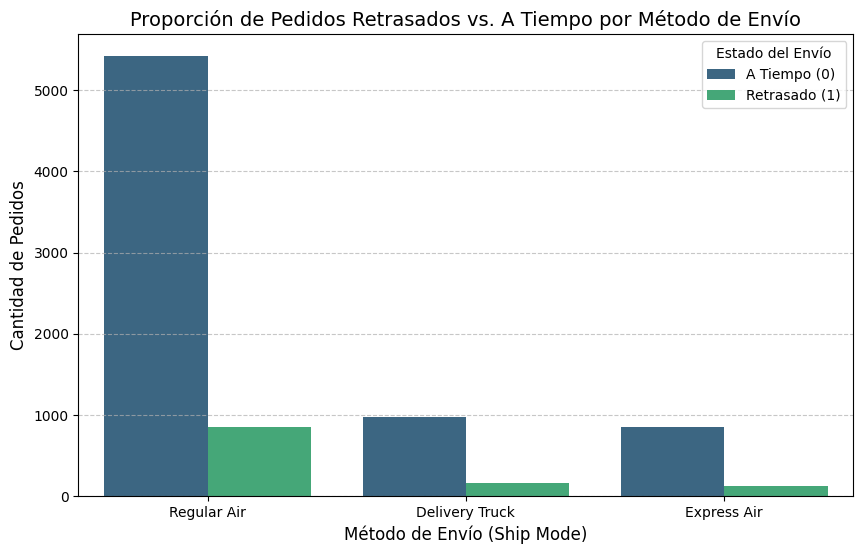

In [5]:
# Importamos librerías para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. LIMPIEZA DE DATOS ---
# Rellenamos los 63 nulos con el promedio de esa columna
promedio_margin = df_ecommerce['Product Base Margin'].mean()
df_ecommerce['Product Base Margin'] = df_ecommerce['Product Base Margin'].fillna(promedio_margin)

# --- 2. CREACIÓN DE VARIABLES (Feature Engineering) ---
# Convertimos las columnas de texto a formato fecha (datetime)
df_ecommerce['Order Date'] = pd.to_datetime(df_ecommerce['Order Date'])
df_ecommerce['Ship Date'] = pd.to_datetime(df_ecommerce['Ship Date'])

# Calculamos los días que tardó el envío
df_ecommerce['Shipping_Days'] = (df_ecommerce['Ship Date'] - df_ecommerce['Order Date']).dt.days

# Creamos nuestra variable Target 'Delayed' (1 = Retrasado, 0 = A tiempo)
# Consideramos retraso si tardó más de 3 días
df_ecommerce['Delayed'] = df_ecommerce['Shipping_Days'].apply(lambda x: 1 if x > 3 else 0)

# --- 3. VISUALIZACIÓN EJECUTIVA (EDA) ---
# Graficamos los retrasos según el método de envío
plt.figure(figsize=(10, 6))
sns.countplot(data=df_ecommerce, x='Ship Mode', hue='Delayed', palette='viridis')

plt.title('Proporción de Pedidos Retrasados vs. A Tiempo por Método de Envío', fontsize=14)
plt.xlabel('Método de Envío (Ship Mode)', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)
plt.legend(title='Estado del Envío', labels=['A Tiempo (0)', 'Retrasado (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [6]:
# Importamos las herramientas de Machine Learning de la librería scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 1. PREPARACIÓN DE LOS DATOS ---

# Seleccionamos las columnas que NO nos sirven para predecir (Features inútiles)
# Descartamos IDs, fechas, nombres y nuestras variables objetivo
columnas_inutiles = ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Customer Name', 'Product Name', 'Delayed', 'Shipping_Days']

# 'X' serán nuestros datos de entrada e 'y' será lo que queremos predecir
X = df_ecommerce.drop(columns=columnas_inutiles)
y = df_ecommerce['Delayed']

# Convertimos las variables categóricas (texto) a columnas numéricas (One-Hot Encoding)
X_numerico = pd.get_dummies(X, drop_first=True)

# Separamos los datos: 80% para que el modelo estudie y aprenda, 20% para tomarle prueba
X_train, X_test, y_train, y_test = train_test_split(X_numerico, y, test_size=0.2, random_state=42)


# --- 2. ENTRENAMIENTO DEL MODELO ---

# Inicializamos el Bosque Aleatorio con 100 árboles de decisión
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenamos el modelo con los datos de estudio
modelo_rf.fit(X_train, y_train)


# --- 3. EVALUACIÓN Y RESULTADOS ---

# Le pedimos al modelo que haga predicciones sobre el 20% de datos de prueba
predicciones = modelo_rf.predict(X_test)

# Mostramos las métricas de evaluación
print("--- RESULTADOS DEL MODELO MACHINE LEARNING ---")
print(f"Precisión General (Accuracy): {accuracy_score(y_test, predicciones) * 100:.2f}%\n")
print("Reporte detallado (Classification Report):")
print(classification_report(y_test, predicciones))

--- RESULTADOS DEL MODELO MACHINE LEARNING ---
Precisión General (Accuracy): 93.27%

Reporte detallado (Classification Report):
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1445
           1       0.73      0.83      0.78       235

    accuracy                           0.93      1680
   macro avg       0.85      0.89      0.87      1680
weighted avg       0.94      0.93      0.93      1680



In [7]:
# Importamos XGBoost y la herramienta de optimización GridSearch
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# --- 1. CONFIGURACIÓN DE LA OPTIMIZACIÓN ---

# Inicializamos el modelo XGBoost
modelo_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Definimos la "cuadrícula" de hiperparámetros que queremos que la máquina pruebe
parametros = {
    'n_estimators': [50, 100],      # Cantidad de árboles
    'max_depth': [3, 5],            # Profundidad máxima de cada árbol
    'learning_rate': [0.1, 0.2]     # Velocidad de aprendizaje
}

# Configuramos la Búsqueda en Cuadrícula con Validación Cruzada (cv=3)
grid_search = GridSearchCV(estimator=modelo_xgb, param_grid=parametros, cv=3, scoring='accuracy', n_jobs=-1)

# --- 2. ENTRENAMIENTO Y BÚSQUEDA ---

print("Optimizando modelo XGBoost con Validación Cruzada... esto puede tardar unos segundos.")
grid_search.fit(X_train, y_train)

# --- 3. EVALUACIÓN DEL MEJOR MODELO ---

# Extraemos el modelo ganador de la búsqueda
mejor_xgb = grid_search.best_estimator_

# Le pedimos que haga predicciones con los datos de prueba
predicciones_xgb = mejor_xgb.predict(X_test)

# Mostramos los resultados del campeón
print("\n--- RESULTADOS XGBOOST OPTIMIZADO ---")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Precisión General (Accuracy): {accuracy_score(y_test, predicciones_xgb) * 100:.2f}%\n")
print("Reporte detallado (Classification Report):")
print(classification_report(y_test, predicciones_xgb))

Optimizando modelo XGBoost con Validación Cruzada... esto puede tardar unos segundos.

--- RESULTADOS XGBOOST OPTIMIZADO ---
Mejores hiperparámetros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Precisión General (Accuracy): 94.05%

Reporte detallado (Classification Report):
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1445
           1       0.71      0.99      0.82       235

    accuracy                           0.94      1680
   macro avg       0.85      0.96      0.89      1680
weighted avg       0.96      0.94      0.94      1680



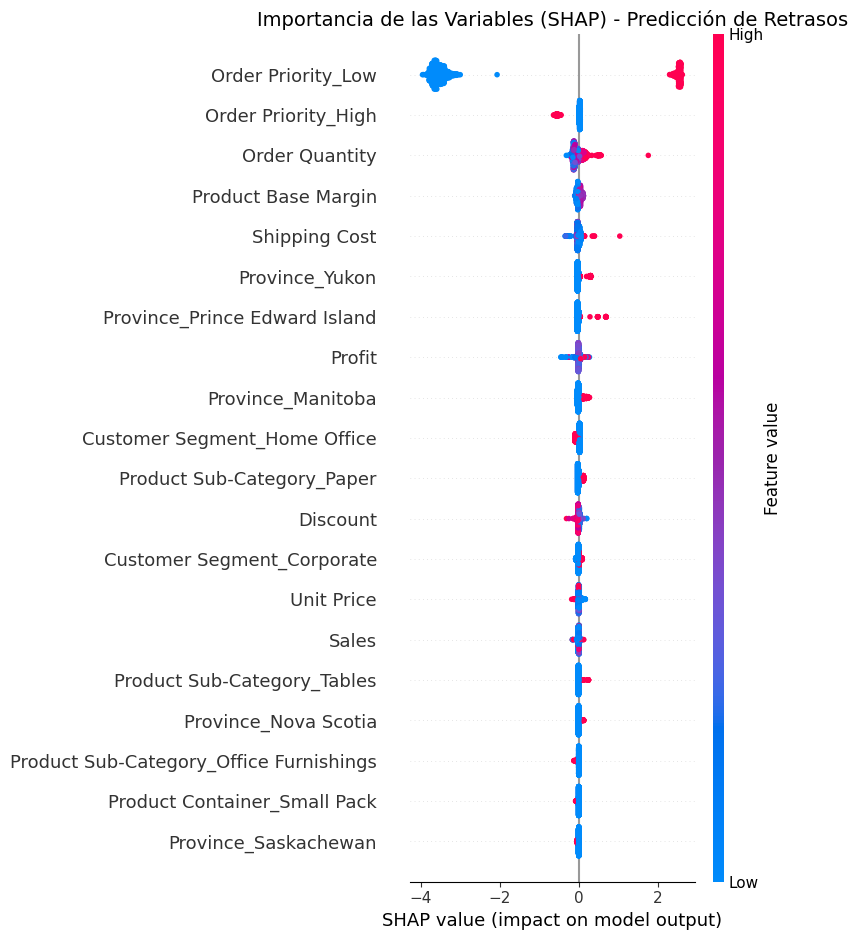

In [8]:
# Importamos la librería SHAP exigida en la rúbrica
import shap
import matplotlib.pyplot as plt

# --- 4. EXPLICABILIDAD DEL MODELO CON SHAP ---

# Inicializamos el explicador usando nuestro modelo campeón (XGBoost)
explainer = shap.TreeExplainer(mejor_xgb)

# Calculamos los valores SHAP para nuestros datos de prueba
shap_values = explainer.shap_values(X_test)

# Generamos el gráfico de resumen (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Importancia de las Variables (SHAP) - Predicción de Retrasos', fontsize=14)
plt.tight_layout()
plt.show()